# Climate Coding Portfolio Assignment

### *Examining climate records from Missoula, Montana*

IN this assignment I chose to examine data from

In [6]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot.pandas ### make interactive plots
import pandas as pd ### handle tabular data

### Download the data

In [26]:
### Make url for data
ncei_url = ('https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&'
            'stations=USC00245740&'
            'startDate=1950-01-01&'
            'endDate=2026-01-01&'
            'units=standard')
ncei_url

 

'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00245740&startDate=1950-01-01&endDate=2026-01-01&units=standard'

In [ ]:
### get the data using the url
### this is a big dataset and took ~3 min to load. Be patient

missoula_df = pd.read_csv(
    ncei_url,

    ### tell python which col to use as index col
    index_col= 'DATE', 

    #### tell python to treat data as a date format
    parse_dates = True,

    ### define the NA values as NaN
    na_values = ['NaN']
    )
missoula_df

,STATION,TOBS
DATE,,
1950-01-01,USC00245740,NaN
1950-01-02,USC00245740,NaN
1950-01-03,USC00245740,-3.0
1950-01-04,USC00245740,6.0
1950-01-05,USC00245740,3.0
...,...,...
2025-12-28,USC00245740,20.0
2025-12-29,USC00245740,20.0
2025-12-30,USC00245740,19.0


<Axes: ylabel='Frequency'>

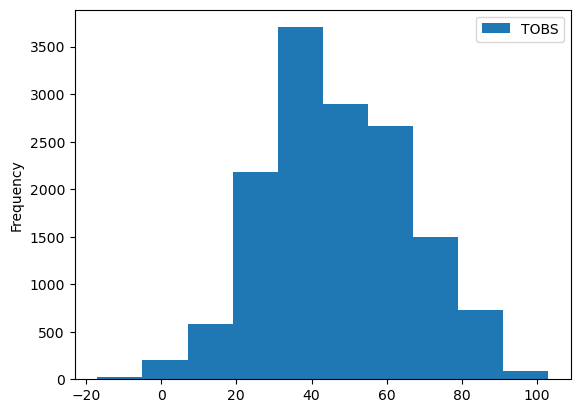

In [ ]:
### check that data was imported into a pandas DataFrame
type(missoula_df)

### checek NA handling
missoula_df.plot.hist()

### looks reasonable- 9/28/26 run

### Clean up Data

In [ ]:
### Drop unused station variable not needed for this analysis
missoula_temp_df = missoula_df[['TOBS']]
missoula_temp_df

### # check the min and max units to find out what units we are in
missoula_temp_df['TOBS'].agg(['min', 'max'])
### The min and max values are in Fahrenheit. We will convert to Celsius for analysis.

min    -17.0
max    103.0
Name: TOBS, dtype: float64

In [ ]:
### change the col names of the temp col to include f for farenheight from documentaion
missoula_temp_df = missoula_temp_df.rename(columns={
    'TOBS': 'temp_f',
})
#missoula_temp_df

,temp_f
DATE,
1950-01-01,NaN
1950-01-02,NaN
1950-01-03,-3.0
1950-01-04,6.0
1950-01-05,3.0
...,...
2025-12-28,20.0
2025-12-29,20.0
2025-12-30,19.0


In [ ]:
### convert f to c nits with a function
def convert_f_to_c(temperature_f):
    """Convert temperature to Celsius"""
    return (temperature_f- 32) *5/9

### apply the function
missoula_temp_df['temp_c'] = (
    missoula_temp_df['temp_f'].apply(convert_f_to_c).round(2))

### inspect result
#missoula_temp_df

,temp_f,temp_c
DATE,,
1950-01-01,NaN,NaN
1950-01-02,NaN,NaN
1950-01-03,-3.0,-19.44
1950-01-04,6.0,-14.44
1950-01-05,3.0,-16.11
...,...,...
2025-12-28,20.0,-6.67
2025-12-29,20.0,-6.67
2025-12-30,19.0,-7.22


### Plot the raw Data

<Axes: title={'center': 'Daily Temperature in Missoula, Montana'}, xlabel='Date', ylabel='Degrees Celcius ($^\\circ$C)'>

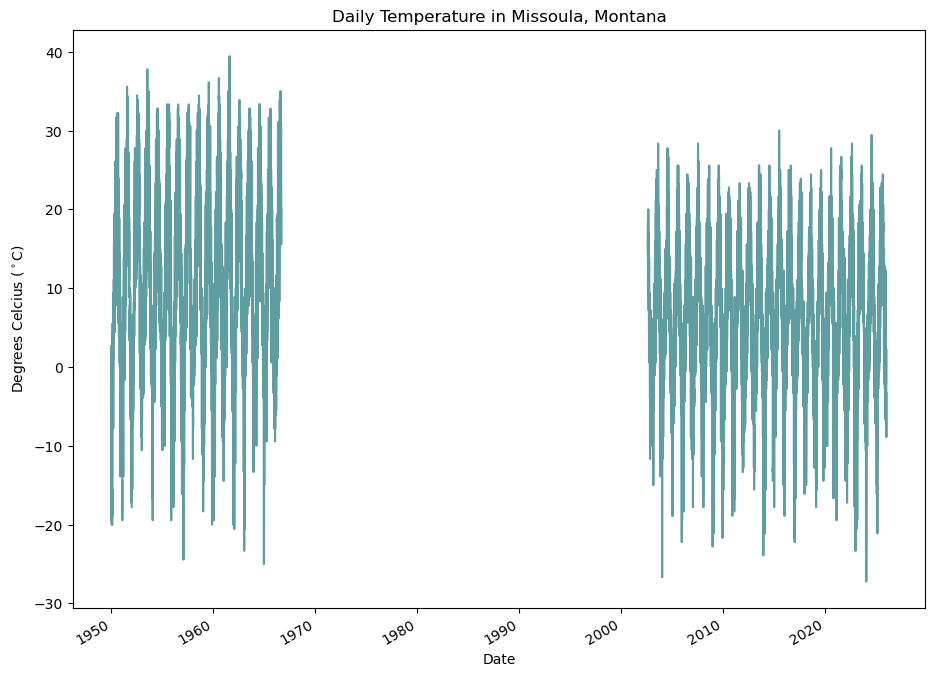

In [35]:
### plot the data in C
missoula_temp_df.plot(
    y = 'temp_c',
    title = 'Daily Temperature in Missoula, Montana',
    xlabel = 'Date',
    ylabel = 'Degrees Celcius ($^\circ$C)',
    figsize = (11,8.5),
    legend=False,
    color = 'cadetblue'
    
)

### Resample and Plot Annually

To get a better sense of the trends over time we plot the mean annual temperatures for the same period.

In [ ]:
### Get the mean annual temps

missoula_ann_temp_df = (
    missoula_temp_df

    ### resample annually (assign date on jan 1)
    .resample('YS')

    ### take the mean
    .mean()
)

missoula_ann_temp_df

<Axes: title={'center': 'Annual Temperature in Missoula, Montana'}, xlabel='Year', ylabel='Degrees Celcius ($^\\circ$C)'>

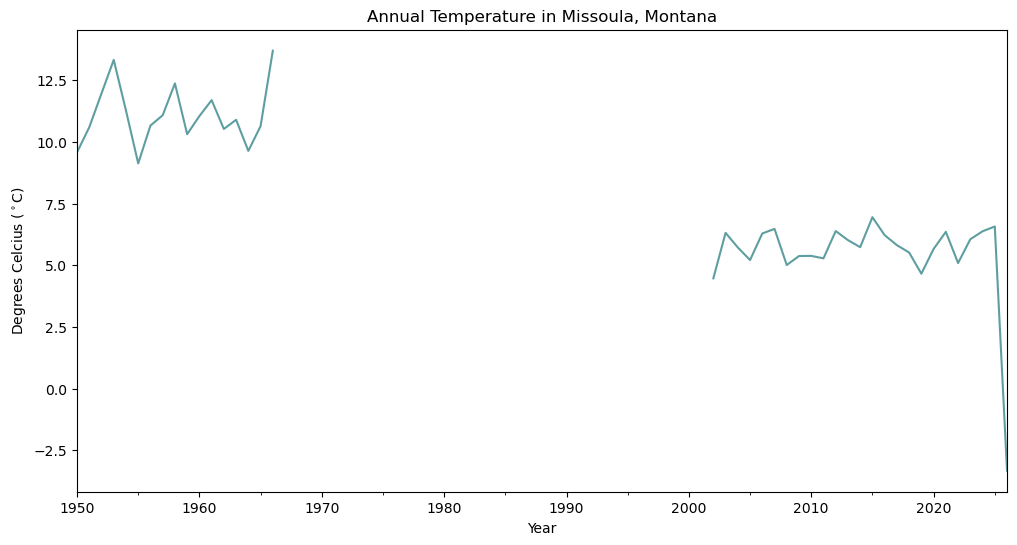

In [37]:
### plot the annual temp in C
missoula_ann_temp_df.plot(
    y = 'temp_c',
    title = 'Annual Temperature in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Degrees Celcius ($^\circ$C)',
    figsize = (12,6),
    legend=False,
    color = 'cadetblue'
    
)

In [40]:
### plot the annual data interactively
missoula_ann_temp_plot = missoula_ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Annual Temperature in Missoula, Montana',
    xlabel = 'Year',
    ylabel = 'Temperature in Degrees Celcius',
    legend=False,
    color = 'cadetblue'
    
)

### View plot
missoula_ann_temp_plot

### Run this fix if the plot is not showing
#hvplot.extension("bokeh")

:Curve   [DATE]   (temp_c)

In [41]:
missoula_ann_temp_plot


:Curve   [DATE]   (temp_c)

### Wrap up and Store Magic

# use store magic (%store) to store var we want later
%store temp_df climate_df